In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




# Langkah 2: Import Dataset

In [72]:
dataset = pd.read_csv('weatherAUS.csv')
pd.unique(dataset['RainTomorrow'])

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [73]:
print("Distribusi Kelas Asli :\n", dataset['RainTomorrow'].value_counts())


Distribusi Kelas Asli :
 RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


# Data Quality Audit


In [74]:
missing_report = pd.DataFrame({
    "missing_count" : dataset.isnull().sum(),
    "missing_percent": dataset.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

missing_report

,missing_count,missing_percent
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559
Pressure9am,15065,10.356799
Pressure3pm,15028,10.331363
WindDir9am,10566,7.263853
WindGustDir,10326,7.098859
WindGustSpeed,10263,7.055548
Humidity3pm,4507,3.098446


In [75]:
dataset = dataset.dropna(subset=['RainTomorrow'])
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')
dataset = dataset.dropna(subset=['Date'])

# reset dataset
dataset = dataset.reset_index(drop=True)

# Langkah 3: Pisahkan Fitur dan Target

In [76]:
x = dataset.drop(columns=['RainTomorrow', 'Date'])
y = dataset['RainTomorrow']



In [77]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=False)


x_train.shape, x_test.shape


((113754, 21), (28439, 21))

# Identifikasi kolom numerik dan kategorial

In [78]:
numeric_cols = x_train.select_dtypes(include=['number']).columns
categorial_cols = x_train.select_dtypes(include=['object']).columns


/tmp/ipykernel_18942/3813024260.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorial_cols = x_train.select_dtypes(include=['object']).columns


# Langkah 4: Melakukan Imputer & One Hot encode

# Imputer

In [79]:


numeric_imputer = IterativeImputer(random_state=42, initial_strategy='median', max_iter=20)
categorial_imputer = SimpleImputer(strategy='most_frequent')

In [80]:
x_train[numeric_cols] = numeric_imputer.fit_transform(x_train[numeric_cols])
x_train[categorial_cols] = categorial_imputer.fit_transform(x_train[categorial_cols])

x_test[numeric_cols] = numeric_imputer.transform(x_test[numeric_cols])
x_test[categorial_cols] = categorial_imputer.transform(x_test[categorial_cols])

/home/muhammad/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


# Encode Categorial 


In [81]:
# encoding fitur categorial

column_transfer = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
train_encode = column_transfer.fit_transform(x_train[categorial_cols])
cat_feature = column_transfer.get_feature_names_out(categorial_cols)

train_encode_df = pd.DataFrame(train_encode, columns=cat_feature, index=x_train.index)

# transform pada data test
test_encode = column_transfer.transform(x_test[categorial_cols])
test_encode_df = pd.DataFrame(test_encode, columns=cat_feature, index=x_test.index)

# gabung kolom baru dan hapus kategori lama
x_train = pd.concat([x_train.drop(columns=categorial_cols), train_encode_df], axis=1)
x_test = pd.concat([x_test.drop(columns=categorial_cols), test_encode_df], axis=1)

/home/muhammad/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


# Label Encode

In [82]:
label_encode = LabelEncoder()

y_train_encode = label_encode.fit_transform(y_train)
y_test_encode = label_encode.transform(y_test)



# Langkah 5: Feature Scalling

In [83]:
scale = StandardScaler()
x_train[numeric_cols] = scale.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scale.fit_transform(x_test[numeric_cols])

# Langkah 6: Split atau Stratified Split

# Menggunakan Algoritma Random Forest Classifier

In [84]:
model_rf = RandomForestClassifier( random_state=0)
model_rf.fit(x_train, y_train_encode)

# prediksi 
y_pred = model_rf.predict(x_test)

akurasi = accuracy_score(y_test_encode, y_pred)

print(f"Model akurasi {akurasi:4f}")


Model akurasi 0.862407


In [85]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=0, class_weight='balanced')
model_rf.fit(x_train, y_train_encode)

# prediksi 
y_pred_straf = model_rf.predict(x_test)

akurasi = accuracy_score(y_test_encode, y_pred_straf)

print(f"Model akurasi {akurasi:4f}")

Model akurasi 0.862196


In [86]:
y_pred_proba = model_rf.predict_proba(x_test)[:, 1]
print(classification_report(y_test_encode, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     22696
           1       0.70      0.56      0.62      5743

    accuracy                           0.86     28439
   macro avg       0.80      0.75      0.77     28439
weighted avg       0.85      0.86      0.86     28439



In [87]:
auc_score = roc_auc_score(y_test_encode, y_pred_proba)
print(f"Skor ROC-AUC: {auc_score:.4f}")

Skor ROC-AUC: 0.8866


# Confusion Matrix

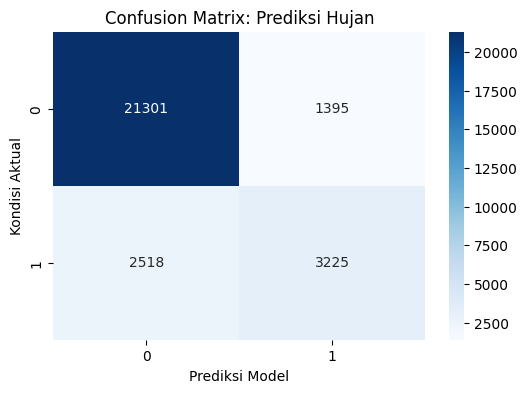

In [88]:
cm = confusion_matrix(y_test_encode, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Prediksi Hujan')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Aktual')
plt.show()

# Explainable AI

--- SHAP Summary Plot: Analisis Fitur Pemicu Hujan ---


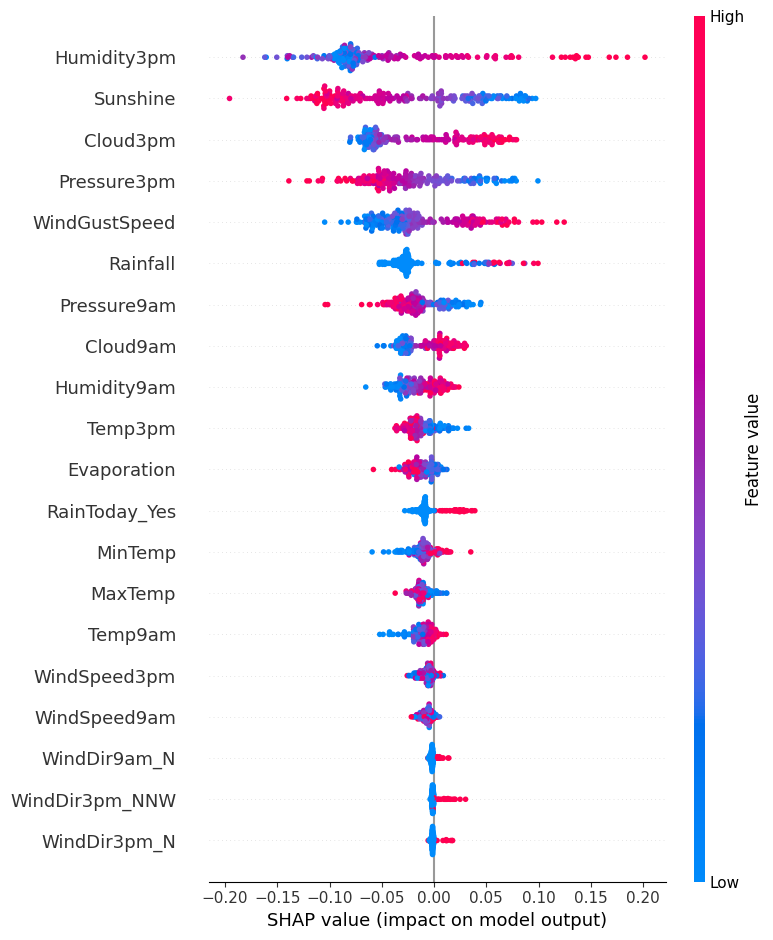

In [89]:
import shap

# Mengambil sampel data agar komputasi kalkulasi SHAP tidak memberatkan memori
x_test_sample = x_test.sample(n=200, random_state=42)

# Inisialisasi TreeExplainer khusus untuk model berbasis Decision Tree/Ensemble
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(x_test_sample)

# Library SHAP pada Random Forest umumnya mengembalikan list array untuk setiap kelas output.
# Kita fokus memetakan faktor pendorong hujan (Kelas 1 / Yes).
shap_values_hujan = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1]

# Memplot ringkasan bobot fitur menggunakan Summary Plot
print("--- SHAP Summary Plot: Analisis Fitur Pemicu Hujan ---")
shap.summary_plot(shap_values_hujan, x_test_sample)

# Simulasi What If

In [90]:
# Mengambil satu baris observasi data dari testing set sebagai dasar eksperimen
data_simulasi = x_test.iloc[[15]].copy()

# Memprediksi probabilitas hujan dengan kondisi data sensor yang normal (apa adanya)
probabilitas_normal = model_rf.predict_proba(data_simulasi)[0][1]
print(f"Probabilitas Hujan (Kondisi Sensor Normal): {probabilitas_normal:.2%}")

# --- Skenario Cuaca Ekstrim ---
# Misalnya, kita asumsikan tiba-tiba kelembapan jam 3 sore melonjak tajam.
# Karena data sebelumnya sudah diproses melalui StandardScaler, 
# penambahan nilai +3.0 setara dengan lonjakan sebesar 3 Standar Deviasi (sangat lembap).
if 'Humidity3pm' in data_simulasi.columns:
    data_simulasi['Humidity3pm'] = data_simulasi['Humidity3pm'] + 3.0
    
    # Menghitung ulang probabilitas setelah skenario kelembapan ekstrim dimasukkan
    probabilitas_ekstrim = model_rf.predict_proba(data_simulasi)[0][1]
    print(f"Probabilitas Hujan (Skenario Kelembapan Ekstrim): {probabilitas_ekstrim:.2%}")
else:
    print("Kolom 'Humidity3pm' tidak ditemukan, sesuaikan nama variabel dengan DataFrame yang ada.")

Probabilitas Hujan (Kondisi Sensor Normal): 3.00%
Probabilitas Hujan (Skenario Kelembapan Ekstrim): 16.00%
